# Predicting Bird Geolocation Region from Latitude and Longitude

This notebook maps bird geolocations (latitude and longitude) to North American regions: US states, Canadian provinces, and other North American countries. It trains a classifier to predict the region and visualizes the results using folium.

## 1. Import Required Libraries
We use pandas, scikit-learn, folium, and geopandas for geospatial mapping and region assignment across North America.

In [1]:
import pandas as pd
import numpy as np
import folium
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

## 2. Load and Inspect Data
Load the NABBP dataset including 'lat_dd' and 'lon_dd'. Birds may be located anywhere in North America (US, Canada, Mexico, Caribbean, Central America).

In [16]:
import os
from birds.settings import load_settings
settings = load_settings()
DATA_PATH = os.path.join(settings.nabbp_data_path, "NABBP_2025_grp_01.csv.gz")
df = pd.read_csv(DATA_PATH, compression='gzip', low_memory=True, engine='pyarrow')
df.head()

,band,original_band,other_bands,event_type,event_date,event_day,event_month,event_year,iso_country,iso_subdivision,...,sex_code,permit,band_status_code,how_obtained_code,who_obtained_code,reporting_method,present_condition,min_age_at_enc,record_source,record_id
0,B88685577705,B88685577705,None,E,09/05/1996,5,9,1996,CA,CA-AB,...,NaN,None,None,1.0,21.0,6.0,5.0,6.25,E,-12887255
1,B68685512971,B68685512971,None,E,09/25/1992,25,9,1992,CA,CA-AB,...,NaN,None,None,1.0,22.0,1.0,5.0,1.25,E,-13054259
2,B68685568815,B68685568815,None,E,09/16/1992,16,9,1992,CA,CA-AB,...,NaN,None,None,1.0,21.0,1.0,3.0,1.25,E,-13057315
3,B24925755707,B24925755707,None,E,09/22/1992,22,9,1992,CA,CA-AB,...,NaN,None,None,1.0,21.0,1.0,3.0,1.25,E,-13056448
4,B94925781537,B94925781537,None,E,09/08/1992,8,9,1992,CA,CA-AB,...,NaN,None,None,1.0,21.0,1.0,3.0,4.25,E,-13052122


In [17]:
# Add a 'season' column based on 'event_month' (1=Jan, ..., 12=Dec)
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'unknown'

df['event_month'] = pd.to_numeric(df['event_month'], errors='coerce')
df = df.dropna(subset=['event_month'])
df['event_month'] = df['event_month'].astype(int)
df['season'] = df['event_month'].apply(month_to_season)

## Visualize Raw Geolocations with a Folium Map
Before preprocessing, let's visualize a sample of bird datapoints from the entire North American region on a map using folium.

In [3]:
# Plot a random sample of 5000 raw datapoints on a folium map and save to HTML
n_points = 5000
sample_df = df.sample(n=n_points, random_state=42) if len(df) > n_points else df
raw_map = folium.Map(location=[40, -100], zoom_start=3)  # Center of North America
for _, row in sample_df.iterrows():
    if pd.notnull(row['lat_dd']) and pd.notnull(row['lon_dd']):
        folium.CircleMarker(
            location=[row['lat_dd'], row['lon_dd']],
            radius=2,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.5
        ).add_to(raw_map)
raw_map.save('north_america_raw_geolocations_map.html')
print('Map saved to north_america_raw_geolocations_map.html')

Map saved to north_america_raw_geolocations_map.html


## 3. Preprocess Geolocation Data
Filter out rows with missing or invalid latitude/longitude values and handle outliers. Use North American bounds for filtering.

In [18]:
# Filter for valid North American latitude and longitude, and remove null island (lat=0, lon=0)
na_lat_bounds = (7, 84)
na_lon_bounds = (-168, -52)
df = df.dropna(subset=['lat_dd', 'lon_dd'])
df = df[(df['lat_dd'] >= na_lat_bounds[0]) & (df['lat_dd'] <= na_lat_bounds[1])]
df = df[(df['lon_dd'] >= na_lon_bounds[0]) & (df['lon_dd'] <= na_lon_bounds[1])]
df = df[~((df['lat_dd'] == 0) & (df['lon_dd'] == 0))]
df[['lat_dd', 'lon_dd']].describe()

,lat_dd,lon_dd
count,1.812955e+06,1.812955e+06
mean,5.761840e+01,-9.910074e+01
std,1.313036e+01,2.069682e+01
min,8.416670e+00,-1.667765e+02
25%,5.150000e+01,-1.005000e+02
50%,6.050000e+01,-9.450000e+01
75%,6.750000e+01,-8.650000e+01
max,8.187439e+01,-5.425000e+01


## 4. Map Coordinates to North American Regions
Assign each (lat_dd, lon_dd) to a US state, Canadian province, or other North American country using a shapefile and geopandas.

In [19]:
north_america = {
    # Northern mainland countries
    "Canada": {"type": "country", "iso": "CAN"},
    "United States": {"type": "country", "iso": "USA"},
    "Mexico": {"type": "country", "iso": "MEX"},
    # Central America countries
    "Belize": {"type": "country", "iso": "BLZ"},
    "Costa Rica": {"type": "country", "iso": "CRI"},
    "El Salvador": {"type": "country", "iso": "SLV"},
    "Guatemala": {"type": "country", "iso": "GTM"},
    "Honduras": {"type": "country", "iso": "HND"},
    "Nicaragua": {"type": "country", "iso": "NIC"},
    "Panama": {"type": "country", "iso": "PAN"},
    # Caribbean countries
    "Antigua and Barbuda": {"type": "country", "iso": "ATG"},
    "Bahamas": {"type": "country", "iso": "BHS"},
    "Barbados": {"type": "country", "iso": "BRB"},
    "Cuba": {"type": "country", "iso": "CUB"},
    "Dominica": {"type": "country", "iso": "DMA"},
    "Dominican Republic": {"type": "country", "iso": "DOM"},
    "Grenada": {"type": "country", "iso": "GRD"},
    "Haiti": {"type": "country", "iso": "HTI"},
    "Jamaica": {"type": "country", "iso": "JAM"},
    "Saint Kitts and Nevis": {"type": "country", "iso": "KNA"},
    "Saint Lucia": {"type": "country", "iso": "LCA"},
    "Saint Vincent and the Grenadines": {"type": "country", "iso": "VCT"},
    "Trinidad and Tobago": {"type": "country", "iso": "TTO"},
    # Territories
    "Puerto Rico": {"type": "territory", "iso": "PRI"},
    "Greenland": {"type": "territory", "iso": "GRL"},
    "Bermuda": {"type": "territory", "iso": "BMU"},
    "Guadeloupe": {"type": "territory", "iso": "GLP"},
    "Martinique": {"type": "territory", "iso": "MTQ"},
    "Aruba": {"type": "territory", "iso": "ABW"},
    "Curaçao": {"type": "territory", "iso": "CUW"},
    "Sint Maarten": {"type": "territory", "iso": "SXM"},
    "Saint Martin": {"type": "territory", "iso": "MAF"},
    "Saint Barthélemy": {"type": "territory", "iso": "BLM"},
    "British Virgin Islands": {"type": "territory", "iso": "VGB"},
    "U.S. Virgin Islands": {"type": "territory", "iso": "VIR"},
    "Turks and Caicos Islands": {"type": "territory", "iso": "TCA"},
    "Cayman Islands": {"type": "territory", "iso": "CYM"},
    "Montserrat": {"type": "territory", "iso": "MSR"},
    "Anguilla": {"type": "territory", "iso": "AIA"},
    "Saint Pierre and Miquelon": {"type": "territory", "iso": "SPM"},
    "Bonaire, Sint Eustatius and Saba": {"type": "territory", "iso": "BES"},
    # Minor/disputed/uninhabited
    "Navassa Island": {"type": "territory", "iso": None},
    "Clipperton Island": {"type": "territory", "iso": None},
}

In [20]:
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [7]:
# Assign country to each row in df based on lat_dd/lon_dd and world geometry
points_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon_dd'], df['lat_dd']), crs=world.crs)
country_name = "ADMIN"
joined = gpd.sjoin(points_gdf, world[['geometry', country_name]], how='left', predicate='within')
df['country_from_geom'] = joined[country_name].values
df['country_from_geom'].value_counts()

country_from_geom
Canada                      1111566
United States of America     408919
Mexico                         2975
Costa Rica                      371
Trinidad and Tobago             349
Cuba                             35
Panama                            5
Greenland                         2
Guatemala                         1
Name: count, dtype: int64

In [ ]:
# Use lat, lon, and season as features for prediction
X = df[['lat_dd', 'lon_dd', 'season']].copy()
# One-hot encode the 'season' column
X = pd.get_dummies(X, columns=['season'])
y = df['country_from_geom']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
# Remove rows with NaN in y_train and corresponding X_train rows
mask = ~y_train.isna()
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

clf.fit(X_train_clean, y_train_clean)
y_pred = clf.predict(X_test)

## 5. Train a Classification Model to Predict Region
Train a RandomForest classifier to predict the region (US state, Canadian province, or other North American country) from latitude and longitude.

Accuracy: 1.00


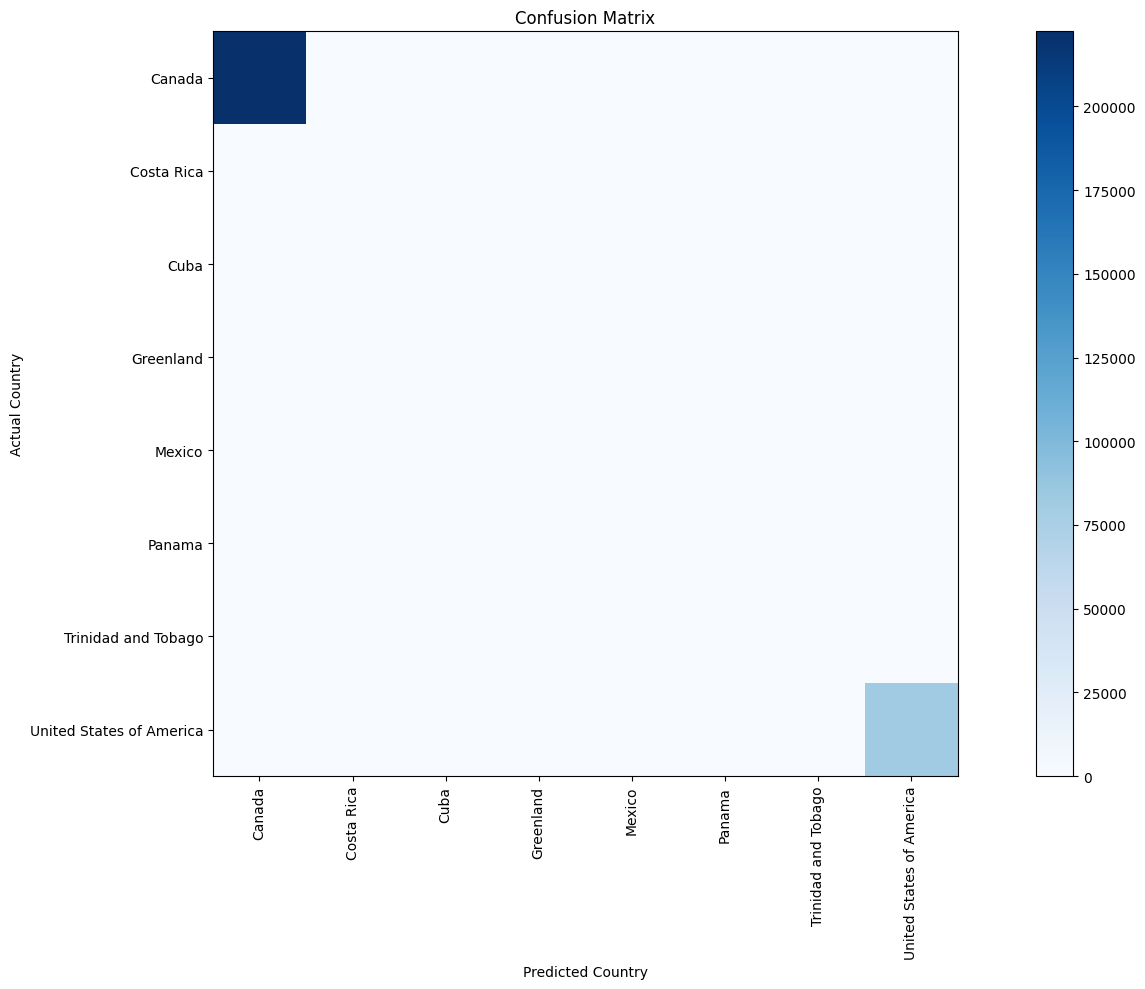

In [9]:
# Evaluate accuracy and show confusion matrix
from sklearn.utils.multiclass import unique_labels
# Remove any rows in y_test or y_pred where y_test is NaN, to avoid comparison errors
mask = ~y_test.isna()
y_test_clean = y_test[mask]
y_pred_clean = pd.Series(y_pred, index=y_test.index)[mask]

acc = accuracy_score(y_test_clean, y_pred_clean)
print(f"Accuracy: {acc:.2f}")
labels = unique_labels(y_test_clean, y_pred_clean)
cm = confusion_matrix(y_test_clean, y_pred_clean, labels=labels)
plt.figure(figsize=(16,10))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Country')
plt.ylabel('Actual Country')
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## 6. Evaluate Model Performance
Assess accuracy and display a confusion matrix for the region predictions.

Accuracy: 1.00


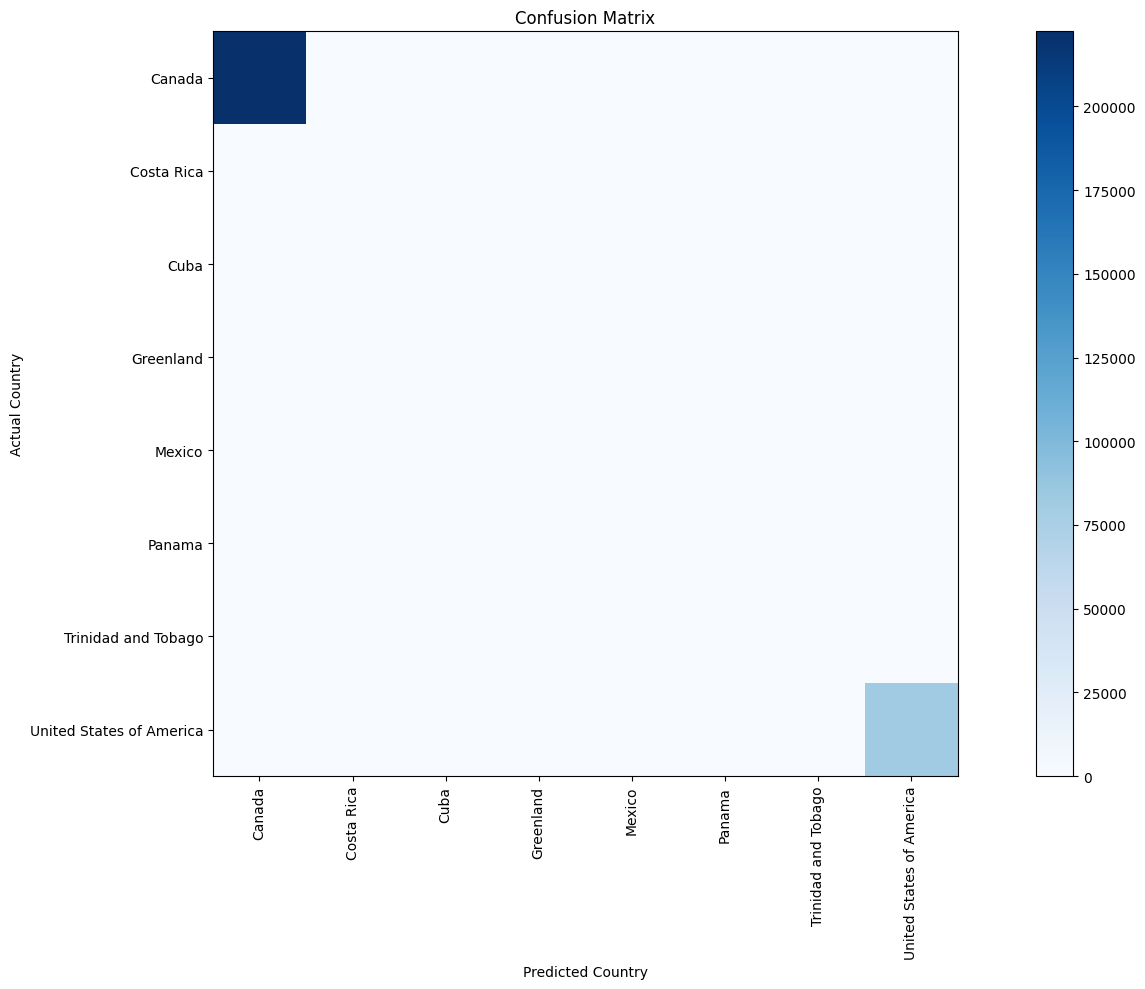

In [10]:
# Evaluate accuracy and show confusion matrix for country prediction
from sklearn.utils.multiclass import unique_labels
mask = ~y_test.isna()
y_test_clean = y_test[mask]
y_pred_clean = pd.Series(y_pred, index=y_test.index)[mask]

acc = accuracy_score(y_test_clean, y_pred_clean)
print(f"Accuracy: {acc:.2f}")
labels = unique_labels(y_test_clean, y_pred_clean)
cm = confusion_matrix(y_test_clean, y_pred_clean, labels=labels)
plt.figure(figsize=(16,10))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Country')
plt.ylabel('Actual Country')
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## 7. Visualize Predictions on a Folium Map
Plot a sample of predicted vs. actual regions on an interactive folium map for North America.

In [11]:
# Visualize a sample of predictions on a folium map (country prediction)
sample = X_test.copy()
sample['actual_country'] = y_test.values
sample['predicted_country'] = y_pred
sample = sample[~sample['actual_country'].isna()]
sample = sample.sample(n=min(200, len(sample)), random_state=42)

m = folium.Map(location=[40, -100], zoom_start=3)  # Center of North America
for _, row in sample.iterrows():
    color = 'green' if row['actual_country'] == row['predicted_country'] else 'red'
    folium.CircleMarker(
        location=[row['lat_dd'], row['lon_dd']],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        popup=f"Actual: {row['actual_country']}, Predicted: {row['predicted_country']}"
    ).add_to(m)
m.save('north_america_predicted_vs_actual_map.html')
print('Map saved to north_america_predicted_vs_actual_map.html')

Map saved to north_america_predicted_vs_actual_map.html
